# 02. 탐색적 데이터 분석

주요 변수의 분포와 채무불이행률 관계를 확인하고 다중공선성을 점검합니다.

> 각 Part는 설정과 입력 데이터를 다시 확인하도록 구성했습니다. 전체 실행과 부분 재실행 모두 가능합니다.

## 1. 단변량 분석

### 0. 패키지 불러오기 및 프로젝트 경로 설정

In [1]:
import warnings
from pathlib import Path
import yaml

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

warnings.filterwarnings('ignore')


def find_project_root(start: Path | None = None) -> Path:
    if start is None:
        start = Path.cwd().resolve()

    candidates = [start] + list(start.parents)
    for path in candidates:
        if (path / "config.yaml").exists():
            return path

    raise FileNotFoundError("config.yaml을 찾지 못했습니다.")


def load_config() -> dict:
    config_path = ROOT / "config.yaml"
    with open(config_path, "r", encoding="utf-8") as f:
        return yaml.safe_load(f)


ROOT = find_project_root()
cfg = load_config()

DATA_DIR = ROOT / cfg["data"]["raw_dir"]
PROCESSED_DIR = ROOT / cfg["data"]["processed_dir"]

FIG_DIR = ROOT / cfg["outputs"]["figures_dir"]
METRIC_DIR = ROOT / cfg["outputs"]["metrics_dir"]
MODEL_DIR = ROOT / cfg["outputs"]["models_dir"]
REPORT_DIR = ROOT / cfg["outputs"]["reports_dir"]

for _path in [PROCESSED_DIR, FIG_DIR, METRIC_DIR, MODEL_DIR, REPORT_DIR]:
    _path.mkdir(parents=True, exist_ok=True)

OUTPUT_DIR = ROOT / "outputs"

print("PROJECT ROOT: .")
print("DATA_DIR    :", DATA_DIR.relative_to(ROOT))
print("FIG_DIR     :", FIG_DIR.relative_to(ROOT))
print("METRIC_DIR  :", METRIC_DIR.relative_to(ROOT))
print("MODEL_DIR   :", MODEL_DIR.relative_to(ROOT))


plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 200)

COLOR_GOOD = '#3b78b8'
COLOR_BAD  = '#c43d3d'

PROJECT ROOT: .
DATA_DIR    : data\raw\home-credit-default-risk
FIG_DIR     : outputs\figures
METRIC_DIR  : outputs\metrics
MODEL_DIR   : outputs\models


### 1. 데이터 로드 + 전처리

In [2]:
print("=" * 70)
print("[1] 데이터 로드 + 사전 전처리")
print("=" * 70)

df = pd.read_csv(DATA_DIR / 'application_train.csv')

# (a) DAYS_EMPLOYED sentinel(365243) → NaN
n_sent = (df['DAYS_EMPLOYED'] == 365243).sum()
df['DAYS_EMPLOYED_ANOM'] = (df['DAYS_EMPLOYED'] == 365243).astype(int)
df.loc[df['DAYS_EMPLOYED'] == 365243, 'DAYS_EMPLOYED'] = np.nan
print(f"  DAYS_EMPLOYED == 365243 → NaN 처리 : {n_sent:,}건")

# (b) 파생: AGE_YEARS, YEARS_EMPLOYED
df['AGE_YEARS']      = -df['DAYS_BIRTH']    / 365.25
df['YEARS_EMPLOYED'] = -df['DAYS_EMPLOYED'] / 365.25
print(f"  파생 변수 생성: AGE_YEARS, YEARS_EMPLOYED")

print(f"\n전처리 후 shape: {df.shape}")
print(f"부도율: {df['TARGET'].mean() * 100:.2f}%")

[1] 데이터 로드 + 사전 전처리


  DAYS_EMPLOYED == 365243 → NaN 처리 : 55,374건
  파생 변수 생성: AGE_YEARS, YEARS_EMPLOYED

전처리 후 shape: (307511, 125)
부도율: 8.07%


### 2. 공통 함수 정의

In [3]:
def group_stats(df, col): # 수치형 변수의 TARGET 그룹별 평균/중앙값/표준편차/관측치 수 + KS 통계량.
    g0 = df.loc[df['TARGET'] == 0, col].dropna()
    g1 = df.loc[df['TARGET'] == 1, col].dropna()
    ks_stat, ks_p = stats.ks_2samp(g0, g1)
    return pd.Series({
        '정상_평균'  : g0.mean(),
        '부도_평균'  : g1.mean(),
        '정상_중앙'  : g0.median(),
        '부도_중앙'  : g1.median(),
        '평균차'     : g1.mean() - g0.mean(),
        'KS_통계량'  : ks_stat,
        'KS_p값'     : ks_p,
        '정상_N'     : len(g0),
        '부도_N'     : len(g1),
    })


def default_rate_by_category(df, col, min_count=500): # 범주형 변수의 카테고리별 부도율과 빈도수.  min_count 미만 카테고리는 제외
    out = (df.groupby(col)['TARGET']
             .agg(['count', 'mean'])
             .rename(columns={'count': '빈도', 'mean': '부도율'}))
    out = out[out['빈도'] >= min_count].sort_values('부도율', ascending=False)
    out['부도율(%)'] = (out['부도율'] * 100).round(2)
    return out

### 3. 그림 3.2 — EXT_SOURCE_1/2/3 KDE


[3] 그림 3.2  EXT_SOURCE_1/2/3 KDE


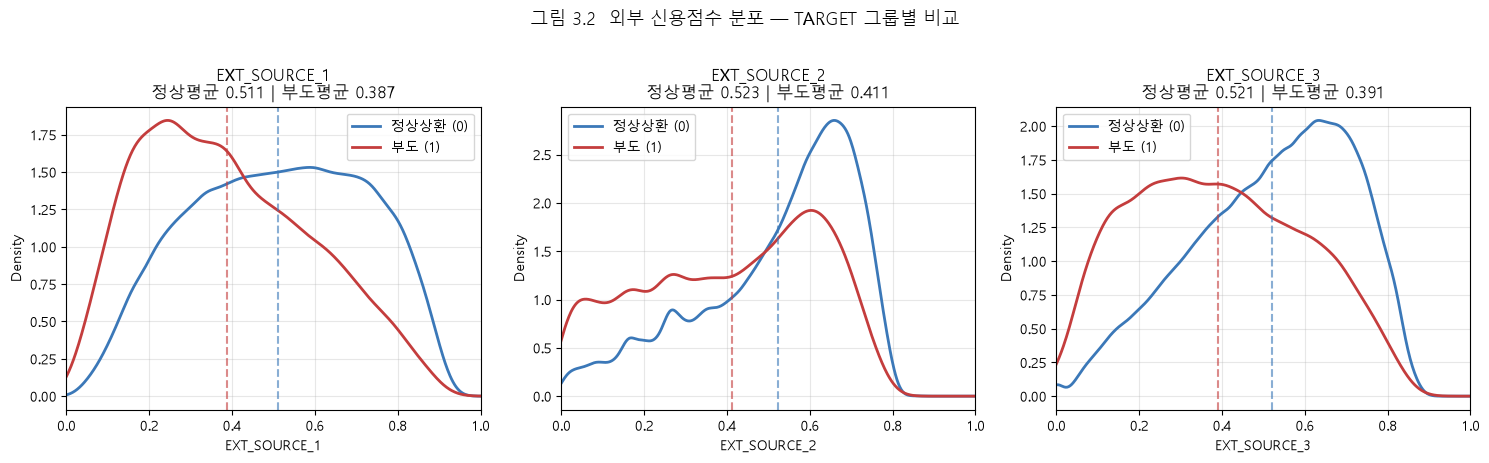

저장: C:\Users\user\Desktop\주진호\05.ICT 인턴십\03.HomeCredit(codex)\outputs\figures\ext_source_default_rate.png

EXT_SOURCE 그룹 비교 통계:
               정상_평균   부도_평균     평균차  KS_통계량
EXT_SOURCE_1  0.5115  0.3870 -0.1245  0.2427
EXT_SOURCE_2  0.5235  0.4109 -0.1125  0.2237
EXT_SOURCE_3  0.5210  0.3907 -0.1303  0.2698


In [4]:
print("\n" + "=" * 70)
print("[3] 그림 3.2  EXT_SOURCE_1/2/3 KDE")
print("=" * 70)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
ext_vars = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']

for ax, v in zip(axes, ext_vars):
    g0 = df.loc[df['TARGET'] == 0, v].dropna()
    g1 = df.loc[df['TARGET'] == 1, v].dropna()
    g0.plot(kind='kde', ax=ax, color=COLOR_GOOD, label='정상상환 (0)', linewidth=2)
    g1.plot(kind='kde', ax=ax, color=COLOR_BAD,  label='부도 (1)',     linewidth=2)
    ax.axvline(g0.mean(), color=COLOR_GOOD, linestyle='--', alpha=0.6)
    ax.axvline(g1.mean(), color=COLOR_BAD,  linestyle='--', alpha=0.6)
    ax.set_title(f'{v}\n정상평균 {g0.mean():.3f} | 부도평균 {g1.mean():.3f}')
    ax.set_xlabel(v); ax.set_ylabel('Density')
    ax.legend(); ax.grid(alpha=0.3)
    ax.set_xlim(0, 1)

fig.suptitle('그림 3.2  외부 신용점수 분포 — TARGET 그룹별 비교', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / 'ext_source_default_rate.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"저장: {FIG_DIR / 'ext_source_default_rate.png'}")

# 통계 출력
ext_stats = pd.DataFrame({v: group_stats(df, v) for v in ext_vars}).T
print("\nEXT_SOURCE 그룹 비교 통계:")
print(ext_stats[['정상_평균','부도_평균','평균차','KS_통계량']].round(4).to_string())

### 4. 그림 3.3 — 연령 / 근속연수 KDE


[4] 그림 3.3  연령 / 근속연수 KDE


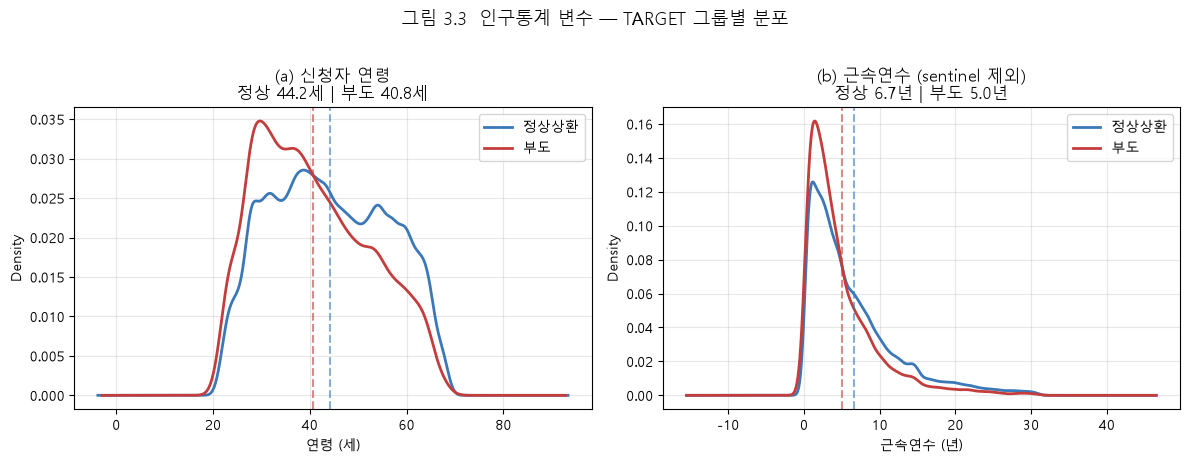

저장: C:\Users\user\Desktop\주진호\05.ICT 인턴십\03.HomeCredit(codex)\outputs\figures\demographic_default_rates.png

인구통계 그룹 비교 통계:
                  정상_평균    부도_평균     평균차  KS_통계량
AGE_YEARS       44.1839  40.7524 -3.4315  0.1219
YEARS_EMPLOYED   6.6753   4.9690 -1.7063  0.1320


In [5]:
print("\n" + "=" * 70)
print("[4] 그림 3.3  연령 / 근속연수 KDE")
print("=" * 70)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# (a) 연령
v = 'AGE_YEARS'
g0 = df.loc[df['TARGET'] == 0, v].dropna()
g1 = df.loc[df['TARGET'] == 1, v].dropna()
g0.plot(kind='kde', ax=axes[0], color=COLOR_GOOD, label='정상상환', linewidth=2)
g1.plot(kind='kde', ax=axes[0], color=COLOR_BAD,  label='부도',     linewidth=2)
axes[0].axvline(g0.mean(), color=COLOR_GOOD, ls='--', alpha=0.6)
axes[0].axvline(g1.mean(), color=COLOR_BAD,  ls='--', alpha=0.6)
axes[0].set_title(f'(a) 신청자 연령\n정상 {g0.mean():.1f}세 | 부도 {g1.mean():.1f}세')
axes[0].set_xlabel('연령 (세)'); axes[0].set_ylabel('Density')
axes[0].legend(); axes[0].grid(alpha=0.3)

# (b) 근속연수 (sentinel 제거 후)
v = 'YEARS_EMPLOYED'
g0 = df.loc[df['TARGET'] == 0, v].dropna()
g1 = df.loc[df['TARGET'] == 1, v].dropna()
# 99 분위로 클리핑 (시각화 안정)
upper = df[v].quantile(0.99)
g0c, g1c = g0[g0 <= upper], g1[g1 <= upper]
g0c.plot(kind='kde', ax=axes[1], color=COLOR_GOOD, label='정상상환', linewidth=2)
g1c.plot(kind='kde', ax=axes[1], color=COLOR_BAD,  label='부도',     linewidth=2)
axes[1].axvline(g0.mean(), color=COLOR_GOOD, ls='--', alpha=0.6)
axes[1].axvline(g1.mean(), color=COLOR_BAD,  ls='--', alpha=0.6)
axes[1].set_title(f'(b) 근속연수 (sentinel 제외)\n정상 {g0.mean():.1f}년 | 부도 {g1.mean():.1f}년')
axes[1].set_xlabel('근속연수 (년)'); axes[1].set_ylabel('Density')
axes[1].legend(); axes[1].grid(alpha=0.3)

fig.suptitle('그림 3.3  인구통계 변수 — TARGET 그룹별 분포', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / 'demographic_default_rates.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"저장: {FIG_DIR / 'demographic_default_rates.png'}")

# 통계
demo_stats = pd.DataFrame({v: group_stats(df, v) for v in ['AGE_YEARS','YEARS_EMPLOYED']}).T
print("\n인구통계 그룹 비교 통계:")
print(demo_stats[['정상_평균','부도_평균','평균차','KS_통계량']].round(4).to_string())

### 5. 그림 3.4 — 대출액 / 소득 KDE (로그 스케일)


[5] 그림 3.4  대출액 / 소득 KDE (로그 스케일)


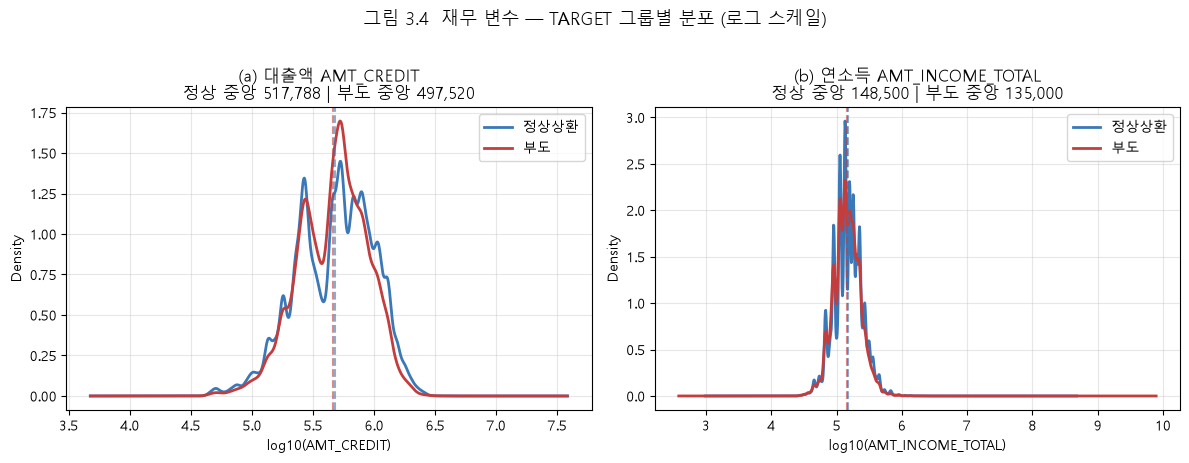

저장: C:\Users\user\Desktop\주진호\05.ICT 인턴십\03.HomeCredit(codex)\outputs\figures\financial_feature_distributions.png

재무 변수 그룹 비교 통계:
                     정상_중앙     부도_중앙  KS_통계량
AMT_CREDIT        517788.0  497520.0    0.07
AMT_INCOME_TOTAL  148500.0  135000.0    0.04


In [6]:
print("\n" + "=" * 70)
print("[5] 그림 3.4  대출액 / 소득 KDE (로그 스케일)")
print("=" * 70)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, v, title_kor in zip(
    axes,
    ['AMT_CREDIT', 'AMT_INCOME_TOTAL'],
    ['(a) 대출액 AMT_CREDIT', '(b) 연소득 AMT_INCOME_TOTAL'],
):
    g0 = df.loc[df['TARGET'] == 0, v].dropna()
    g1 = df.loc[df['TARGET'] == 1, v].dropna()
    log0, log1 = np.log10(g0[g0 > 0]), np.log10(g1[g1 > 0])
    log0.plot(kind='kde', ax=ax, color=COLOR_GOOD, label='정상상환', linewidth=2)
    log1.plot(kind='kde', ax=ax, color=COLOR_BAD,  label='부도',     linewidth=2)
    ax.axvline(log0.mean(), color=COLOR_GOOD, ls='--', alpha=0.6)
    ax.axvline(log1.mean(), color=COLOR_BAD,  ls='--', alpha=0.6)
    ax.set_title(f'{title_kor}\n정상 중앙 {g0.median():,.0f} | 부도 중앙 {g1.median():,.0f}')
    ax.set_xlabel(f'log10({v})'); ax.set_ylabel('Density')
    ax.legend(); ax.grid(alpha=0.3)

fig.suptitle('그림 3.4  재무 변수 — TARGET 그룹별 분포 (로그 스케일)', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / 'financial_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"저장: {FIG_DIR / 'financial_feature_distributions.png'}")

fin_stats = pd.DataFrame({v: group_stats(df, v) for v in ['AMT_CREDIT','AMT_INCOME_TOTAL']}).T
print("\n재무 변수 그룹 비교 통계:")
print(fin_stats[['정상_중앙','부도_중앙','KS_통계량']].round(2).to_string())

### 6. 그림 3.5 — 교육수준 / 직업 부도율 막대


[6] 그림 3.5  범주형 변수 부도율 막대


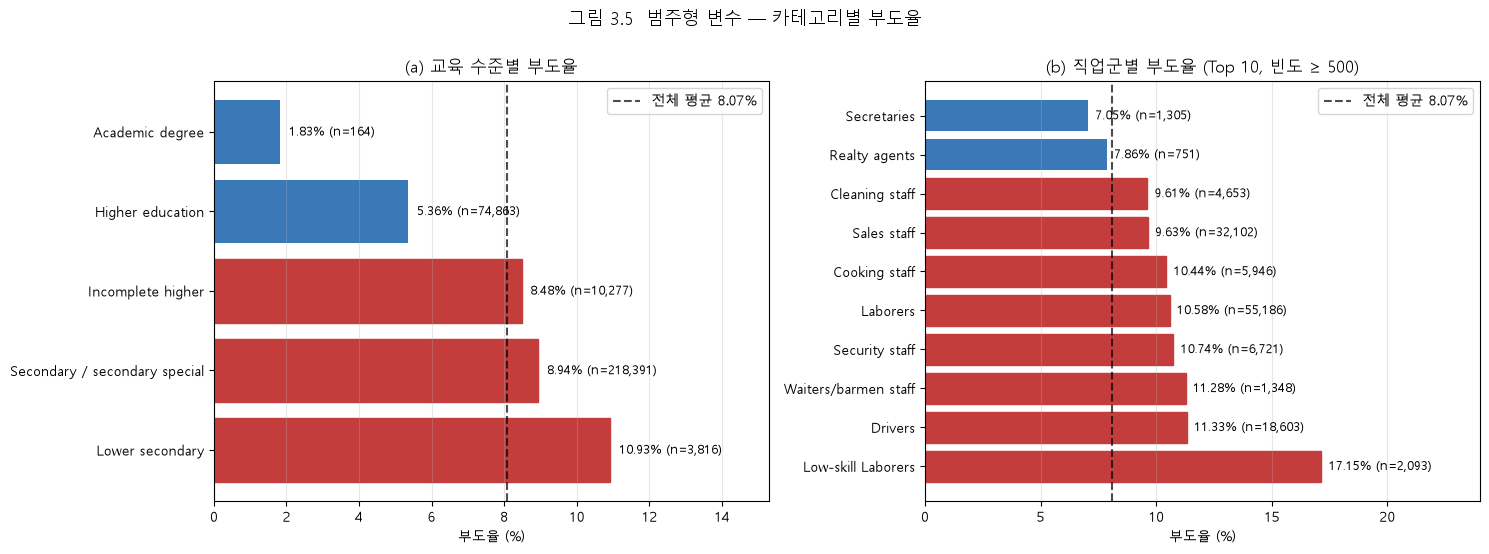

저장: C:\Users\user\Desktop\주진호\05.ICT 인턴십\03.HomeCredit(codex)\outputs\figures\categorical_default_rates.png

교육 수준별 부도율:
                                   빈도  부도율(%)
NAME_EDUCATION_TYPE                          
Lower secondary                  3816   10.93
Secondary / secondary special  218391    8.94
Incomplete higher               10277    8.48
Higher education                74863    5.36
Academic degree                   164    1.83

직업군별 부도율 (Top 10):
                         빈도  부도율(%)
OCCUPATION_TYPE                    
Low-skill Laborers     2093   17.15
Drivers               18603   11.33
Waiters/barmen staff   1348   11.28
Security staff         6721   10.74
Laborers              55186   10.58
Cooking staff          5946   10.44
Sales staff           32102    9.63
Cleaning staff         4653    9.61
Realty agents           751    7.86
Secretaries            1305    7.05


In [7]:
print("\n" + "=" * 70)
print("[6] 그림 3.5  범주형 변수 부도율 막대")
print("=" * 70)

baseline = df['TARGET'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# (a) NAME_EDUCATION_TYPE
edu = default_rate_by_category(df, 'NAME_EDUCATION_TYPE', min_count=100)
bars = axes[0].barh(edu.index, edu['부도율(%)'], color=COLOR_GOOD)
# baseline 보다 높은 카테고리만 부도 색
for bar, val in zip(bars, edu['부도율(%)']):
    if val > baseline:
        bar.set_color(COLOR_BAD)
axes[0].axvline(baseline, color='black', ls='--', alpha=0.7,
                label=f'전체 평균 {baseline:.2f}%')
axes[0].set_title('(a) 교육 수준별 부도율')
axes[0].set_xlabel('부도율 (%)'); axes[0].legend(); axes[0].grid(axis='x', alpha=0.3)
# 옆에 빈도 표시
for i, (val, n) in enumerate(zip(edu['부도율(%)'], edu['빈도'])):
    axes[0].text(val + 0.1, i, f' {val:.2f}% (n={n:,})', va='center', fontsize=9)
axes[0].set_xlim(0, edu['부도율(%)'].max() * 1.4)

# (b) OCCUPATION_TYPE (Top 10)
occ = default_rate_by_category(df, 'OCCUPATION_TYPE', min_count=500).head(10)
bars = axes[1].barh(occ.index, occ['부도율(%)'], color=COLOR_GOOD)
for bar, val in zip(bars, occ['부도율(%)']):
    if val > baseline:
        bar.set_color(COLOR_BAD)
axes[1].axvline(baseline, color='black', ls='--', alpha=0.7,
                label=f'전체 평균 {baseline:.2f}%')
axes[1].set_title('(b) 직업군별 부도율 (Top 10, 빈도 ≥ 500)')
axes[1].set_xlabel('부도율 (%)'); axes[1].legend(); axes[1].grid(axis='x', alpha=0.3)
for i, (val, n) in enumerate(zip(occ['부도율(%)'], occ['빈도'])):
    axes[1].text(val + 0.1, i, f' {val:.2f}% (n={n:,})', va='center', fontsize=9)
axes[1].set_xlim(0, occ['부도율(%)'].max() * 1.4)

fig.suptitle('그림 3.5  범주형 변수 — 카테고리별 부도율', y=1.00, fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / 'categorical_default_rates.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"저장: {FIG_DIR / 'categorical_default_rates.png'}")

print("\n교육 수준별 부도율:")
print(edu[['빈도', '부도율(%)']].to_string())
print("\n직업군별 부도율 (Top 10):")
print(occ[['빈도', '부도율(%)']].to_string())

### 7. [표 3.2] 가설 요약표

In [8]:
print("\n" + "=" * 70)
print("[7] [표 3.2] 단변량 EDA 가설 요약")
print("=" * 70)

# 수치형 변수 통합 표
num_vars = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
            'AGE_YEARS', 'YEARS_EMPLOYED',
            'AMT_CREDIT', 'AMT_INCOME_TOTAL']
summary = pd.DataFrame({v: group_stats(df, v) for v in num_vars}).T

# 관계 강도 라벨링
def label_strength(ks):
    if ks >= 0.10: return '강함 ★★★'
    if ks >= 0.05: return '중간 ★★'
    if ks >= 0.02: return '약함 ★'
    return '미약'

summary['관계 강도'] = summary['KS_통계량'].apply(label_strength)
summary['방향']      = np.where(summary['평균차'] > 0, '부도층 ↑', '부도층 ↓')

# 가독성 좋게 정렬
summary_view = summary[['정상_평균','부도_평균','평균차','KS_통계량','방향','관계 강도']]
summary_view = summary_view.round(4).sort_values('KS_통계량', ascending=False)
print("\n수치형 변수 ([표 3.2] 본체):")
print(summary_view.to_string())

# 범주형 강도: 최댓값-최솟값 부도율 차
edu_gap = edu['부도율(%)'].max() - edu['부도율(%)'].min()
occ_gap = occ['부도율(%)'].max() - occ['부도율(%)'].min()
print(f"\n범주형 변수:")
print(f"  NAME_EDUCATION_TYPE : 부도율 범위 {edu_gap:.2f}%p  (Min~Max)")
print(f"  OCCUPATION_TYPE     : 부도율 범위 {occ_gap:.2f}%p  (Min~Max)")

# CSV 저장
summary_view.to_csv(METRIC_DIR / 'hypothesis_test_summary.csv', encoding='utf-8-sig')
print(f"\n저장: {METRIC_DIR / 'hypothesis_test_summary.csv'}")

print("\n" + "=" * 70)
print("=" * 70)


[7] [표 3.2] 단변량 EDA 가설 요약



수치형 변수 ([표 3.2] 본체):
                        정상_평균        부도_평균         평균차  KS_통계량     방향   관계 강도
EXT_SOURCE_3           0.5210       0.3907     -0.1303  0.2698  부도층 ↓  강함 ★★★
EXT_SOURCE_1           0.5115       0.3870     -0.1245  0.2427  부도층 ↓  강함 ★★★
EXT_SOURCE_2           0.5235       0.4109     -0.1125  0.2237  부도층 ↓  강함 ★★★
YEARS_EMPLOYED         6.6753       4.9690     -1.7063  0.1320  부도층 ↓  강함 ★★★
AGE_YEARS             44.1839      40.7524     -3.4315  0.1219  부도층 ↓  강함 ★★★
AMT_CREDIT        602648.2820  557778.5277 -44869.7543  0.0695  부도층 ↓   중간 ★★
AMT_INCOME_TOTAL  169077.7223  165611.7609  -3465.9614  0.0374  부도층 ↓    약함 ★

범주형 변수:
  NAME_EDUCATION_TYPE : 부도율 범위 9.10%p  (Min~Max)
  OCCUPATION_TYPE     : 부도율 범위 10.10%p  (Min~Max)

저장: C:\Users\user\Desktop\주진호\05.ICT 인턴십\03.HomeCredit(codex)\outputs\metrics\hypothesis_test_summary.csv



## 2. 변수 관계 및 다중공선성

### 0. 패키지 불러오기 및 프로젝트 경로 설정

In [9]:
import warnings
from pathlib import Path
import yaml

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')


def find_project_root(start: Path | None = None) -> Path:
    if start is None:
        start = Path.cwd().resolve()

    candidates = [start] + list(start.parents)
    for path in candidates:
        if (path / "config.yaml").exists():
            return path

    raise FileNotFoundError("config.yaml을 찾지 못했습니다.")


def load_config() -> dict:
    config_path = ROOT / "config.yaml"
    with open(config_path, "r", encoding="utf-8") as f:
        return yaml.safe_load(f)


ROOT = find_project_root()
cfg = load_config()

DATA_DIR = ROOT / cfg["data"]["raw_dir"]
PROCESSED_DIR = ROOT / cfg["data"]["processed_dir"]

FIG_DIR = ROOT / cfg["outputs"]["figures_dir"]
METRIC_DIR = ROOT / cfg["outputs"]["metrics_dir"]
MODEL_DIR = ROOT / cfg["outputs"]["models_dir"]
REPORT_DIR = ROOT / cfg["outputs"]["reports_dir"]

for _path in [PROCESSED_DIR, FIG_DIR, METRIC_DIR, MODEL_DIR, REPORT_DIR]:
    _path.mkdir(parents=True, exist_ok=True)

OUTPUT_DIR = ROOT / "outputs"

print("PROJECT ROOT: .")
print("DATA_DIR    :", DATA_DIR.relative_to(ROOT))
print("FIG_DIR     :", FIG_DIR.relative_to(ROOT))
print("METRIC_DIR  :", METRIC_DIR.relative_to(ROOT))
print("MODEL_DIR   :", MODEL_DIR.relative_to(ROOT))


plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 200)

COLOR_GOOD = '#3b78b8'
COLOR_BAD  = '#c43d3d'

PROJECT ROOT: .
DATA_DIR    : data\raw\home-credit-default-risk
FIG_DIR     : outputs\figures
METRIC_DIR  : outputs\metrics
MODEL_DIR   : outputs\models


### 1. 데이터 로드 + 전처리

In [10]:
print("=" * 70)
print("[1] 데이터 로드 + 사전 전처리")
print("=" * 70)

df = pd.read_csv(DATA_DIR / 'application_train.csv')

# DAYS_EMPLOYED sentinel(365243) → NaN, 더미 생성
df['DAYS_EMPLOYED_ANOM'] = (df['DAYS_EMPLOYED'] == 365243).astype(int)
df.loc[df['DAYS_EMPLOYED'] == 365243, 'DAYS_EMPLOYED'] = np.nan

# 파생
df['AGE_YEARS']      = -df['DAYS_BIRTH']    / 365.25
df['YEARS_EMPLOYED'] = -df['DAYS_EMPLOYED'] / 365.25

print(f"전처리 후 shape: {df.shape}")
print(f"부도율: {df['TARGET'].mean() * 100:.2f}%")

[1] 데이터 로드 + 사전 전처리


전처리 후 shape: (307511, 125)
부도율: 8.07%


### 2. 그림 3.6 — 핵심 12변수 상관 히트맵


[2] 그림 3.6  핵심 수치형 변수 상관 히트맵


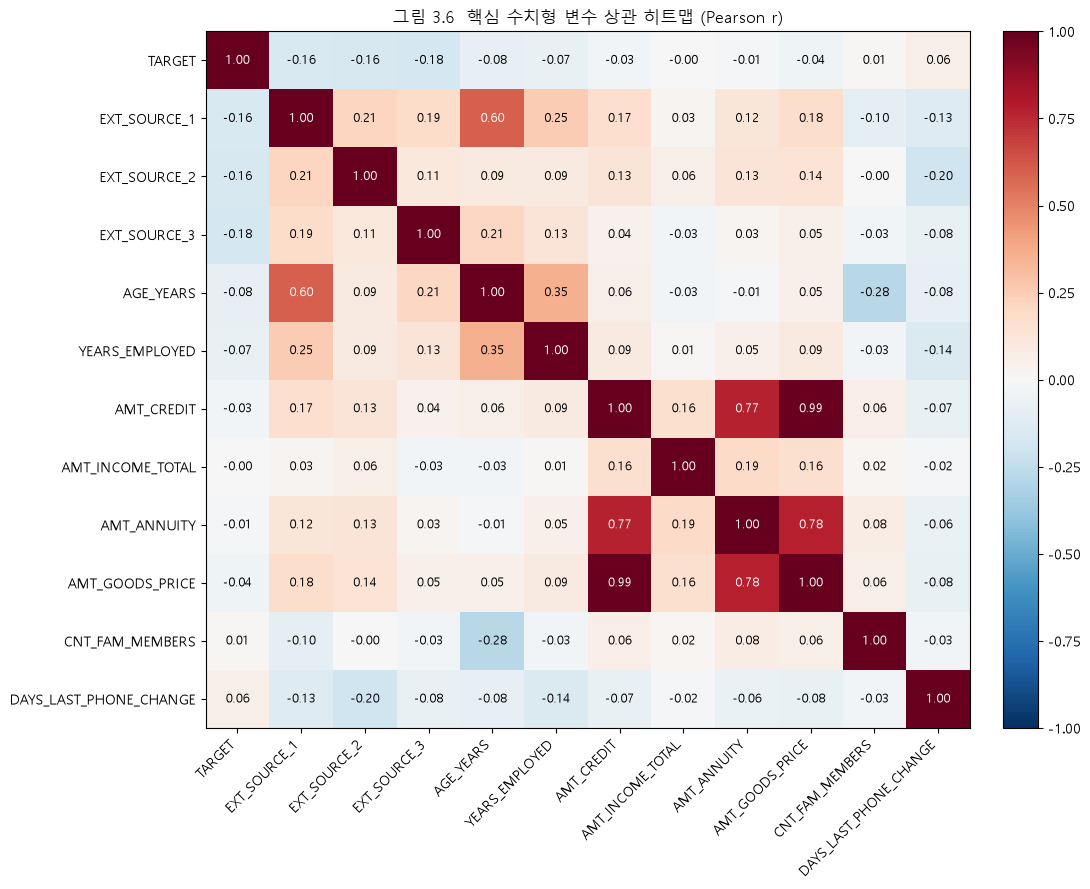

저장: C:\Users\user\Desktop\주진호\05.ICT 인턴십\03.HomeCredit(codex)\outputs\figures\numeric_feature_correlation_heatmap.png

TARGET과의 상관계수 (절댓값 기준 내림차순):
EXT_SOURCE_3             -0.1789
EXT_SOURCE_2             -0.1605
EXT_SOURCE_1             -0.1553
AGE_YEARS                -0.0782
YEARS_EMPLOYED           -0.0750
DAYS_LAST_PHONE_CHANGE    0.0552
AMT_GOODS_PRICE          -0.0396
AMT_CREDIT               -0.0304
AMT_ANNUITY              -0.0128
CNT_FAM_MEMBERS           0.0093
AMT_INCOME_TOTAL         -0.0040


In [11]:
print("\n" + "=" * 70)
print("[2] 그림 3.6  핵심 수치형 변수 상관 히트맵")
print("=" * 70)

core_vars = [
    'TARGET',
    'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
    'AGE_YEARS', 'YEARS_EMPLOYED',
    'AMT_CREDIT', 'AMT_INCOME_TOTAL', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
    'CNT_FAM_MEMBERS', 'DAYS_LAST_PHONE_CHANGE',
]
corr = df[core_vars].corr()

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(core_vars)))
ax.set_yticks(range(len(core_vars)))
ax.set_xticklabels(core_vars, rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(core_vars, fontsize=10)

# 수치 어노테이션
for i in range(len(core_vars)):
    for j in range(len(core_vars)):
        val = corr.iloc[i, j]
        color = 'white' if abs(val) > 0.55 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                color=color, fontsize=8.5)

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title('그림 3.6  핵심 수치형 변수 상관 히트맵 (Pearson r)', fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / 'numeric_feature_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"저장: {FIG_DIR / 'numeric_feature_correlation_heatmap.png'}")

# TARGET과의 상관 정렬
print("\nTARGET과의 상관계수 (절댓값 기준 내림차순):")
target_corr = (corr['TARGET'].drop('TARGET')
               .sort_values(key=lambda s: s.abs(), ascending=False))
print(target_corr.round(4).to_string())

### 3. 그림 3.7 — EXT_SOURCE 상호상관 + 10분위 부도율


[3] 그림 3.7  EXT_SOURCE 심층 분석

EXT_SOURCE 3종 + TARGET 상관행렬:
              EXT_SOURCE_1  EXT_SOURCE_2  EXT_SOURCE_3  TARGET
EXT_SOURCE_1        1.0000        0.2140        0.1868 -0.1553
EXT_SOURCE_2        0.2140        1.0000        0.1092 -0.1605
EXT_SOURCE_3        0.1868        0.1092        1.0000 -0.1789
TARGET             -0.1553       -0.1605       -0.1789  1.0000


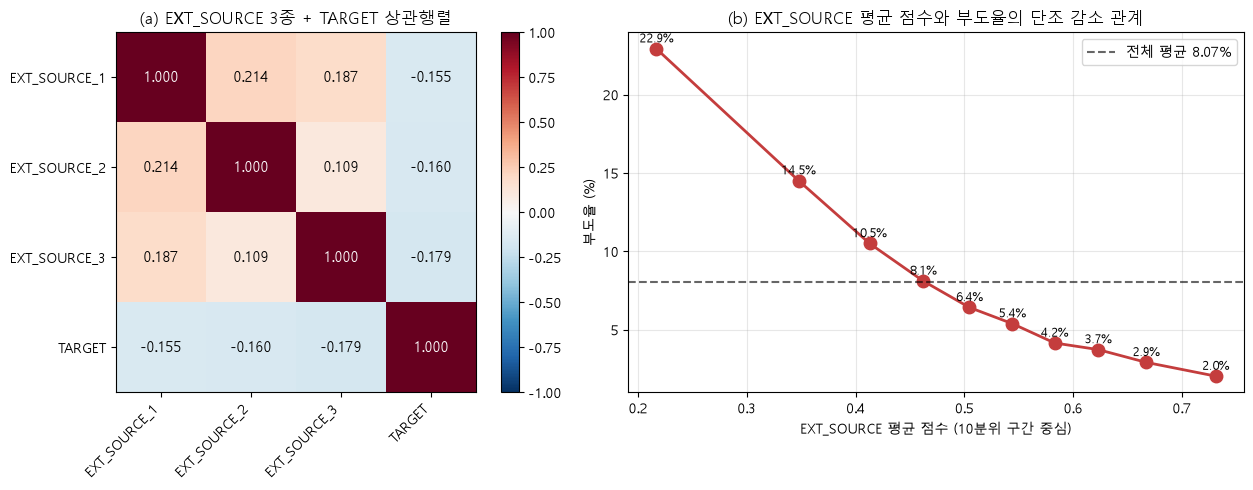


저장: C:\Users\user\Desktop\주진호\05.ICT 인턴십\03.HomeCredit(codex)\outputs\figures\ext_source_decile_default_rate.png

10분위별 부도율:
 ext_decile  bin_center     n  default_rate
          0      0.2168 30734        0.2293
          1      0.3476 30734        0.1451
          2      0.4130 30734        0.1050
          3      0.4621 30734        0.0811
          4      0.5046 30734        0.0643
          5      0.5442 30733        0.0539
          6      0.5831 30736        0.0415
          7      0.6230 30732        0.0374
          8      0.6672 30734        0.0292
          9      0.7311 30734        0.0204


In [12]:
print("\n" + "=" * 70)
print("[3] 그림 3.7  EXT_SOURCE 심층 분석")
print("=" * 70)

ext_corr = df[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'TARGET']].corr()
print("\nEXT_SOURCE 3종 + TARGET 상관행렬:")
print(ext_corr.round(4).to_string())

# EXT_SOURCE 평균 → 10분위 부도율
df['EXT_SOURCE_MEAN'] = df[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].mean(axis=1)
df_bin = df.dropna(subset=['EXT_SOURCE_MEAN']).copy()
df_bin['ext_decile'] = pd.qcut(df_bin['EXT_SOURCE_MEAN'], q=10,
                                labels=False, duplicates='drop')
bin_stats = (df_bin.groupby('ext_decile')
             .agg(bin_center=('EXT_SOURCE_MEAN', 'mean'),
                  default_rate=('TARGET', 'mean'),
                  n=('TARGET', 'count'))
             .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) EXT_SOURCE 4×4 히트맵
im = axes[0].imshow(ext_corr, cmap='RdBu_r', vmin=-1, vmax=1)
axes[0].set_xticks(range(4))
axes[0].set_yticks(range(4))
axes[0].set_xticklabels(ext_corr.columns, rotation=45, ha='right')
axes[0].set_yticklabels(ext_corr.columns)
for i in range(4):
    for j in range(4):
        val = ext_corr.iloc[i, j]
        color = 'white' if abs(val) > 0.55 else 'black'
        axes[0].text(j, i, f'{val:.3f}', ha='center', va='center',
                     color=color, fontsize=11)
axes[0].set_title('(a) EXT_SOURCE 3종 + TARGET 상관행렬')
plt.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

# (b) EXT_SOURCE 평균 점수 → 부도율 (단조성)
baseline = df['TARGET'].mean() * 100
axes[1].plot(bin_stats['bin_center'], bin_stats['default_rate'] * 100,
             'o-', color=COLOR_BAD, linewidth=2, markersize=9)
axes[1].axhline(baseline, color='black', ls='--', alpha=0.6,
                label=f'전체 평균 {baseline:.2f}%')
axes[1].set_xlabel('EXT_SOURCE 평균 점수 (10분위 구간 중심)')
axes[1].set_ylabel('부도율 (%)')
axes[1].set_title('(b) EXT_SOURCE 평균 점수와 부도율의 단조 감소 관계')
axes[1].legend()
axes[1].grid(alpha=0.3)
for _, r in bin_stats.iterrows():
    axes[1].text(r['bin_center'], r['default_rate'] * 100 + 0.4,
                 f"{r['default_rate']*100:.1f}%", ha='center', fontsize=8.5)

plt.tight_layout()
plt.savefig(FIG_DIR / 'ext_source_decile_default_rate.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n저장: {FIG_DIR / 'ext_source_decile_default_rate.png'}")

print("\n10분위별 부도율:")
print(bin_stats[['ext_decile', 'bin_center', 'n', 'default_rate']].round(4).to_string(index=False))

### 4. 그림 3.8 — EXT_SOURCE 결측 패턴 × TARGET


[4] 그림 3.8  EXT_SOURCE 결측 패턴의 정보성

[4-1] 변수별 결측 vs 비결측 부도율:
          변수  결측 부도율(%)  비결측 부도율(%)  결측-비결측(%p)   결측 N
EXT_SOURCE_1       8.52        7.50        1.02 173378
EXT_SOURCE_2       7.88        8.07       -0.19    660
EXT_SOURCE_3       9.31        7.77        1.55  60965

[4-2] EXT_SOURCE 3종 중 비결측 개수별 부도율:
 EXT_NOT_NA_COUNT      n  default_rate(%)
                0    172             8.14
                1  36737             9.92
                2 161013             8.18
                3 109589             7.30


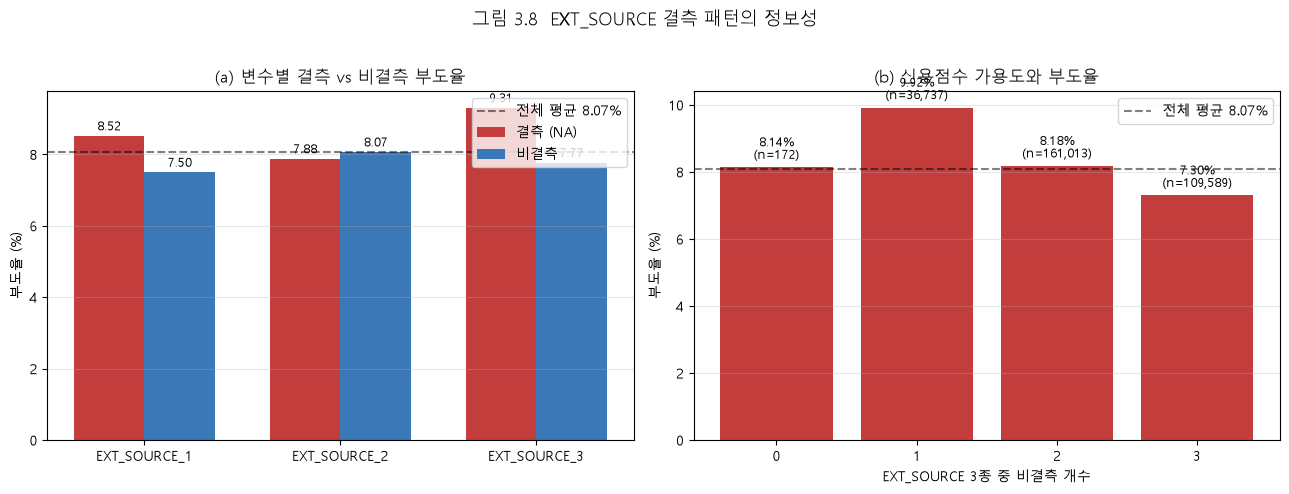


저장: C:\Users\user\Desktop\주진호\05.ICT 인턴십\03.HomeCredit(codex)\outputs\figures\ext_source_missingness.png


In [13]:
print("\n" + "=" * 70)
print("[4] 그림 3.8  EXT_SOURCE 결측 패턴의 정보성")
print("=" * 70)

# (a) 변수별 결측/비결측 부도율
rows = []
for v in ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']:
    na_rate    = df.loc[df[v].isna(),  'TARGET'].mean() * 100
    notna_rate = df.loc[df[v].notna(), 'TARGET'].mean() * 100
    rows.append({
        '변수'           : v,
        '결측 부도율(%)'  : round(na_rate, 2),
        '비결측 부도율(%)': round(notna_rate, 2),
        '결측-비결측(%p)' : round(na_rate - notna_rate, 2),
        '결측 N'         : df[v].isna().sum(),
    })
na_compare = pd.DataFrame(rows)
print("\n[4-1] 변수별 결측 vs 비결측 부도율:")
print(na_compare.to_string(index=False))

# (b) EXT_SOURCE 비결측 개수별 부도율
df['EXT_NOT_NA_COUNT'] = df[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].notna().sum(axis=1)
count_stats = (df.groupby('EXT_NOT_NA_COUNT')
               .agg(n=('TARGET', 'count'), default_rate=('TARGET', 'mean'))
               .reset_index())
count_stats['default_rate(%)'] = (count_stats['default_rate'] * 100).round(2)
print("\n[4-2] EXT_SOURCE 3종 중 비결측 개수별 부도율:")
print(count_stats[['EXT_NOT_NA_COUNT', 'n', 'default_rate(%)']].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

# (a)
x_pos = np.arange(3)
width = 0.36
axes[0].bar(x_pos - width/2, na_compare['결측 부도율(%)'],   width,
            color=COLOR_BAD,  label='결측 (NA)')
axes[0].bar(x_pos + width/2, na_compare['비결측 부도율(%)'], width,
            color=COLOR_GOOD, label='비결측')
axes[0].axhline(baseline, color='black', ls='--', alpha=0.5,
                label=f'전체 평균 {baseline:.2f}%')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3'])
axes[0].set_ylabel('부도율 (%)')
axes[0].set_title('(a) 변수별 결측 vs 비결측 부도율')
axes[0].legend(loc='upper right')
axes[0].grid(axis='y', alpha=0.3)
for i, (na, notna) in enumerate(zip(na_compare['결측 부도율(%)'],
                                     na_compare['비결측 부도율(%)'])):
    axes[0].text(i - width/2, na + 0.15,    f'{na:.2f}',    ha='center', fontsize=9)
    axes[0].text(i + width/2, notna + 0.15, f'{notna:.2f}', ha='center', fontsize=9)

# (b)
axes[1].bar(count_stats['EXT_NOT_NA_COUNT'], count_stats['default_rate(%)'],
            color=COLOR_BAD)
axes[1].axhline(baseline, color='black', ls='--', alpha=0.5,
                label=f'전체 평균 {baseline:.2f}%')
axes[1].set_xticks([0, 1, 2, 3])
axes[1].set_xlabel('EXT_SOURCE 3종 중 비결측 개수')
axes[1].set_ylabel('부도율 (%)')
axes[1].set_title('(b) 신용점수 가용도와 부도율')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)
for _, r in count_stats.iterrows():
    axes[1].text(r['EXT_NOT_NA_COUNT'], r['default_rate(%)'] + 0.25,
                 f"{r['default_rate(%)']:.2f}%\n(n={int(r['n']):,})",
                 ha='center', fontsize=9)

fig.suptitle('그림 3.8  EXT_SOURCE 결측 패턴의 정보성', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / 'ext_source_missingness.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n저장: {FIG_DIR / 'ext_source_missingness.png'}")

### 5. [표 3.2] 다중공선성 점검

In [14]:
print("\n" + "=" * 70)
print("[5] [표 3.2] 다중공선성 점검 (|r| ≥ 0.7 변수쌍)")
print("=" * 70)

# 수치형 + 표준편차 > 0 + ID/TARGET 제외
num_df = df.select_dtypes(include=[np.number]).copy()
num_df = num_df.drop(columns=['SK_ID_CURR', 'TARGET',
                              'AGE_YEARS', 'YEARS_EMPLOYED',
                              'EXT_SOURCE_MEAN', 'EXT_NOT_NA_COUNT',
                              'DAYS_EMPLOYED_ANOM'], errors='ignore')
num_df = num_df.loc[:, num_df.std() > 0]

corr_all = num_df.corr().abs()
mask = np.triu(np.ones(corr_all.shape, dtype=bool), k=1)
upper = corr_all.where(mask)

# 페어 추출
pairs = []
for col in upper.columns:
    s = upper[col].dropna()
    s = s[s >= 0.7]
    for idx, v in s.items():
        pairs.append({'var1': idx, 'var2': col, 'abs_r': round(v, 4)})
pairs_df = pd.DataFrame(pairs).sort_values('abs_r', ascending=False).reset_index(drop=True)

print(f"\n전체 수치형 변수: {num_df.shape[1]}개")
print(f"|r| ≥ 0.7 변수쌍: {len(pairs_df)}쌍")
print(f"|r| ≥ 0.9 변수쌍: {(pairs_df['abs_r'] >= 0.9).sum()}쌍")

print(f"\n상위 20쌍:")
print(pairs_df.head(20).to_string(index=False))

pairs_df.to_csv(METRIC_DIR / 'multicollinearity_diagnostics.csv',
                encoding='utf-8-sig', index=False)
print(f"\n저장: {METRIC_DIR / 'multicollinearity_diagnostics.csv'}  (전체 {len(pairs_df)}쌍)")

# 핵심 변수 한정 |r| ≥ 0.5
print("\n핵심 변수 한정 |r| ≥ 0.5 페어 (모형화 직접 영향):")
core_no_target = [c for c in core_vars if c != 'TARGET']
core_only = df[core_no_target].corr().abs()
mask_c = np.triu(np.ones(core_only.shape, dtype=bool), k=1)
core_upper = core_only.where(mask_c)
core_pairs = []
for col in core_upper.columns:
    s = core_upper[col].dropna()
    s = s[s >= 0.5]
    for idx, v in s.items():
        core_pairs.append({'var1': idx, 'var2': col, 'abs_r': round(v, 4)})
core_pairs_df = pd.DataFrame(core_pairs).sort_values('abs_r', ascending=False)
print(core_pairs_df.to_string(index=False))


[5] [표 3.2] 다중공선성 점검 (|r| ≥ 0.7 변수쌍)



전체 수치형 변수: 104개
|r| ≥ 0.7 변수쌍: 126쌍
|r| ≥ 0.9 변수쌍: 61쌍

상위 20쌍:
                       var1                         var2  abs_r
            YEARS_BUILD_AVG             YEARS_BUILD_MEDI 0.9985
   OBS_30_CNT_SOCIAL_CIRCLE     OBS_60_CNT_SOCIAL_CIRCLE 0.9985
              FLOORSMIN_AVG               FLOORSMIN_MEDI 0.9972
              FLOORSMAX_AVG               FLOORSMAX_MEDI 0.9970
              ENTRANCES_AVG               ENTRANCES_MEDI 0.9969
              ELEVATORS_AVG               ELEVATORS_MEDI 0.9961
             COMMONAREA_AVG              COMMONAREA_MEDI 0.9960
             LIVINGAREA_AVG              LIVINGAREA_MEDI 0.9956
             APARTMENTS_AVG              APARTMENTS_MEDI 0.9951
           BASEMENTAREA_AVG            BASEMENTAREA_MEDI 0.9943
       LIVINGAPARTMENTS_AVG        LIVINGAPARTMENTS_MEDI 0.9938
YEARS_BEGINEXPLUATATION_AVG YEARS_BEGINEXPLUATATION_MEDI 0.9938
               LANDAREA_AVG                LANDAREA_MEDI 0.9916
    NONLIVINGAPARTMENTS_AVG     NONLIVI